# MobileNetV3-Small Partial Unfreeze + Penalty Regularization

## Motivation
ResNet18 (11M params) overfits heavily on this dataset (~5k samples, 779 melanoma). MobileNetV3-Small has ~2.5M params and we further reduce active parameters by only unfreezing the last 3 blocks of the backbone, leaving the rest frozen.

## Architecture
MobileNetV3-Small `model.features` has 13 children:
- `[0]` stem conv
- `[1ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ7]` MBConv blocks
- `[8]` head conv

`unfreeze_last_n_blocks=3` trains only the last 3 blocks + classifier.

## Lambda Sweep
| Run | l1_lambda | l2_lambda | Purpose |
|-----|-----------|-----------|--------|
| 0   | 0         | 0         | Baseline (no penalty) |
| 1   | 0         | 1e-4      | Mild L2 |
| 2   | 0         | 1e-3      | Moderate L2 |
| 3   | 1e-4      | 0         | Mild L1 |
| 4   | 1e-3      | 0         | Moderate L1 |

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import fbeta_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataloader import get_dataloaders
from src.models.mobilenet import get_mobilenet_v3_small
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
print('CUDA available:', torch.cuda.is_available())
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

CUDA available: True
MPS available: False
Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../../data/splits/train.csv',
    val_csv='../../data/splits/val.csv',
    test_csv='../../data/splits/test.csv',
    image_dir='../../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../../data/splits/train.csv')
num_melanoma = (train_df['label'] == 0).sum()
num_nevus = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([6.0244], device='cuda:0')


## Lambda Sweep

In [5]:
all_results = {}

In [6]:
# --- Baseline (no penalty) ---
num_epochs = 20
run_label = 'Baseline'
l1_lambda = 0.0
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: Baseline (l1=0.0, l2=0.0) ===


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\Dylan Gay/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 167MB/s]


  Epoch [1/20] | Train Loss: 0.8982, F2: 0.6160 | Val Loss: 0.8145, F2: 0.6352 | LR: 1.00e-04
    -> New best val F2: 0.6352


  Epoch [2/20] | Train Loss: 0.6881, F2: 0.6847 | Val Loss: 0.7096, F2: 0.6567 | LR: 1.00e-04
    -> New best val F2: 0.6567


  Epoch [3/20] | Train Loss: 0.5883, F2: 0.7361 | Val Loss: 0.6673, F2: 0.6840 | LR: 1.00e-04
    -> New best val F2: 0.6840


...

  Epoch [16/20] | Train Loss: 0.2459, F2: 0.8961 | Val Loss: 1.1239, F2: 0.6350 | LR: 1.00e-04


  Epoch [17/20] | Train Loss: 0.2189, F2: 0.9120 | Val Loss: 1.0294, F2: 0.6611 | LR: 1.00e-04


  Epoch [18/20] | Train Loss: 0.2064, F2: 0.9139 | Val Loss: 0.8860, F2: 0.6937 | LR: 1.00e-04


  Epoch [19/20] | Train Loss: 0.2084, F2: 0.9120 | Val Loss: 1.0478, F2: 0.6671 | LR: 5.00e-05


  Epoch [20/20] | Train Loss: 0.1778, F2: 0.9316 | Val Loss: 1.1005, F2: 0.6566 | LR: 5.00e-05
Best val F2 for Baseline: 0.7401


In [7]:
# --- L2=1e-3 ---
num_epochs = 20
run_label = 'L2=1e-3'
l1_lambda = 0.0
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L2=1e-3 (l1=0.0, l2=0.001) ===


  Epoch [1/20] | Train Loss: 0.9033, F2: 0.6180 | Val Loss: 0.8150, F2: 0.6383 | LR: 1.00e-04
    -> New best val F2: 0.6383


  Epoch [2/20] | Train Loss: 0.6939, F2: 0.6829 | Val Loss: 0.7100, F2: 0.6643 | LR: 1.00e-04
    -> New best val F2: 0.6643


  Epoch [3/20] | Train Loss: 0.5943, F2: 0.7326 | Val Loss: 0.6692, F2: 0.6877 | LR: 1.00e-04
    -> New best val F2: 0.6877


  Epoch [4/20] | Train Loss: 0.5572, F2: 0.7410 | Val Loss: 0.6428, F2: 0.7042 | LR: 1.00e-04
    -> New best val F2: 0.7042


...

  Epoch [16/20] | Train Loss: 0.2778, F2: 0.8798 | Val Loss: 0.8762, F2: 0.6848 | LR: 5.00e-05


  Epoch [17/20] | Train Loss: 0.2606, F2: 0.8904 | Val Loss: 0.8560, F2: 0.6824 | LR: 5.00e-05


  Epoch [18/20] | Train Loss: 0.2540, F2: 0.8910 | Val Loss: 0.7637, F2: 0.7127 | LR: 5.00e-05
    -> New best val F2: 0.7127


  Epoch [19/20] | Train Loss: 0.2506, F2: 0.8979 | Val Loss: 0.8482, F2: 0.6889 | LR: 5.00e-05


  Epoch [20/20] | Train Loss: 0.2402, F2: 0.8955 | Val Loss: 0.9209, F2: 0.7001 | LR: 5.00e-05
Best val F2 for L2=1e-3: 0.7127


In [8]:
# --- L1=1e-3 ---
num_epochs = 20
run_label = 'L1=1e-3'
l1_lambda = 1e-3
l2_lambda = 0.0

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3 (l1=0.001, l2=0.0) ===


  Epoch [1/20] | Train Loss: 0.9375, F2: 0.6096 | Val Loss: 0.8381, F2: 0.6387 | LR: 1.00e-04
    -> New best val F2: 0.6387


  Epoch [2/20] | Train Loss: 0.7427, F2: 0.6763 | Val Loss: 0.7345, F2: 0.6634 | LR: 1.00e-04
    -> New best val F2: 0.6634


  Epoch [3/20] | Train Loss: 0.6557, F2: 0.7105 | Val Loss: 0.7037, F2: 0.6804 | LR: 1.00e-04
    -> New best val F2: 0.6804


  Epoch [4/20] | Train Loss: 0.6208, F2: 0.7243 | Val Loss: 0.6852, F2: 0.6826 | LR: 1.00e-04
    -> New best val F2: 0.6826


...

  Epoch [16/20] | Train Loss: 0.4644, F2: 0.7881 | Val Loss: 0.5909, F2: 0.7097 | LR: 1.00e-04


  Epoch [17/20] | Train Loss: 0.4356, F2: 0.7960 | Val Loss: 0.5827, F2: 0.7187 | LR: 1.00e-04
    -> New best val F2: 0.7187


  Epoch [18/20] | Train Loss: 0.4452, F2: 0.7991 | Val Loss: 0.6006, F2: 0.6978 | LR: 1.00e-04


  Epoch [19/20] | Train Loss: 0.4426, F2: 0.8054 | Val Loss: 0.6175, F2: 0.7012 | LR: 1.00e-04


  Epoch [20/20] | Train Loss: 0.4385, F2: 0.8103 | Val Loss: 0.6056, F2: 0.7173 | LR: 1.00e-04
Best val F2 for L1=1e-3: 0.7187


In [9]:
# --- L1=1e-3 and L2=1e-3 ---
num_epochs = 40
run_label = 'L1=1e-3, L2=1e-3'
l1_lambda = 1e-3
l2_lambda = 1e-3

print(f'=== Run: {run_label} (l1={l1_lambda}, l2={l2_lambda}) ===')
set_seed(42)

model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=4, factor=0.5, min_lr=1e-6)

history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
best_val_f2 = 0.0
best_state = None

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_f2'].append(train_metrics['f2'])
    history['val_f2'].append(val_metrics['f2'])

    scheduler.step(val_metrics['f2'])
    current_lr = optimizer.param_groups[0]['lr']

    print(f"  Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'    -> New best val F2: {best_val_f2:.4f}')

all_results[run_label] = {'history': history, 'best_val_f2': best_val_f2, 'best_state': best_state}
print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')

=== Run: L1=1e-3, L2=1e-3 (l1=0.001, l2=0.001) ===


  Epoch [1/40] | Train Loss: 0.9491, F2: 0.6023 | Val Loss: 0.8503, F2: 0.6434 | LR: 1.00e-04
    -> New best val F2: 0.6434


  Epoch [2/40] | Train Loss: 0.7586, F2: 0.6713 | Val Loss: 0.7507, F2: 0.6571 | LR: 1.00e-04
    -> New best val F2: 0.6571


  Epoch [3/40] | Train Loss: 0.6720, F2: 0.7058 | Val Loss: 0.7226, F2: 0.6667 | LR: 1.00e-04
    -> New best val F2: 0.6667


  Epoch [4/40] | Train Loss: 0.6356, F2: 0.7183 | Val Loss: 0.7049, F2: 0.6731 | LR: 1.00e-04
    -> New best val F2: 0.6731


...

  Epoch [36/40] | Train Loss: 0.3863, F2: 0.8288 | Val Loss: 0.6220, F2: 0.7120 | LR: 1.25e-05


  Epoch [37/40] | Train Loss: 0.3741, F2: 0.8438 | Val Loss: 0.6100, F2: 0.7228 | LR: 1.25e-05


  Epoch [38/40] | Train Loss: 0.3677, F2: 0.8429 | Val Loss: 0.6002, F2: 0.7312 | LR: 1.25e-05


  Epoch [39/40] | Train Loss: 0.3725, F2: 0.8436 | Val Loss: 0.5906, F2: 0.7382 | LR: 1.25e-05


  Epoch [40/40] | Train Loss: 0.3647, F2: 0.8377 | Val Loss: 0.6139, F2: 0.7259 | LR: 1.25e-05
Best val F2 for L1=1e-3, L2=1e-3: 0.7476


## Compare Overfitting: Train vs Val F2 Gap

In [10]:
print(f"{'Run':<12} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'Gap (T-V)':>9}")
print('-' * 70)
for run_label, result in all_results.items():
    h = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2 = h['val_f2'][-1]
    gap = final_train_f2 - final_val_f2
    print(f"{run_label:<12} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>9.4f}")

Run          | Best Val F2 | Final Train F2 | Final Val F2 | Gap (T-V)
----------------------------------------------------------------------
Baseline     |      0.7401 |         0.9316 |       0.6566 |    0.2750
L2=1e-3      |      0.7127 |         0.8955 |       0.7001 |    0.1954
L1=1e-3      |      0.7187 |         0.8103 |       0.7173 |    0.0930
L1=1e-3, L2=1e-3 |      0.7476 |         0.8377 |       0.7259 |    0.1118


## Compare Overfitting: Train vs Val Loss Gap

In [11]:
print(f"{'Run':<12} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print("-" * 62)
for run_label, result in all_results.items():
    h = result["history"]
    final_train_loss = h["train_loss"][-1]
    final_val_loss = h["val_loss"][-1]
    gap = final_val_loss - final_train_loss
    print(f"{run_label:<12} | {final_train_loss:>15.4f} | {final_val_loss:>14.4f} | {gap:>14.4f}")


Run          | Final Train Loss | Final Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
Baseline     |          0.1778 |         1.1005 |         0.9227
L2=1e-3      |          0.2402 |         0.9209 |         0.6807
L1=1e-3      |          0.4385 |         0.6056 |         0.1671
L1=1e-3, L2=1e-3 |          0.3647 |         0.6139 |         0.2492


## Compare Test Loss, Recall and F2 for all Runs

In [12]:
from sklearn.metrics import recall_score

print(f"{'Run':<12} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test F2':>9}")
print('-' * 50)

for run_label, result in all_results.items():
    eval_model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss = 0.0
    total_samples = 0
    all_labels_test = []
    all_probs_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs = eval_model(images)
            loss = criterion_eval(outputs, labels_dev)
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs_test.extend(probs.cpu().numpy())
            all_labels_test.extend(labels.numpy())

    test_loss = running_loss / total_samples

    val_probs_run, val_labels_run = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = eval_model(images.to(device))
            probs = torch.sigmoid(outputs).squeeze(1)
            val_probs_run.extend(probs.cpu().numpy())
            val_labels_run.extend(labels.numpy())

    thresholds = np.arange(0.01, 0.9, 0.01)
    f2_scores = [fbeta_score(val_labels_run, (np.array(val_probs_run) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f2_scores)]

    preds = (np.array(all_probs_test) >= best_threshold).astype(int)
    test_f2 = fbeta_score(all_labels_test, preds, beta=2, pos_label=1, zero_division=0)
    test_recall = recall_score(all_labels_test, preds, pos_label=1, zero_division=0)

    print(f"{run_label:<12} | {test_loss:>9.4f} | {test_recall:>11.4f} | {test_f2:>9.4f}")

Run          | Test Loss | Test Recall |   Test F2
--------------------------------------------------
Baseline     |    0.7521 |      0.7605 |    0.7079
L2=1e-3      |    0.6690 |      0.7964 |    0.7356
L1=1e-3      |    0.5762 |      0.8683 |    0.7214
L1=1e-3, L2=1e-3 |    0.5994 |      0.8204 |    0.7256


## Training Curves

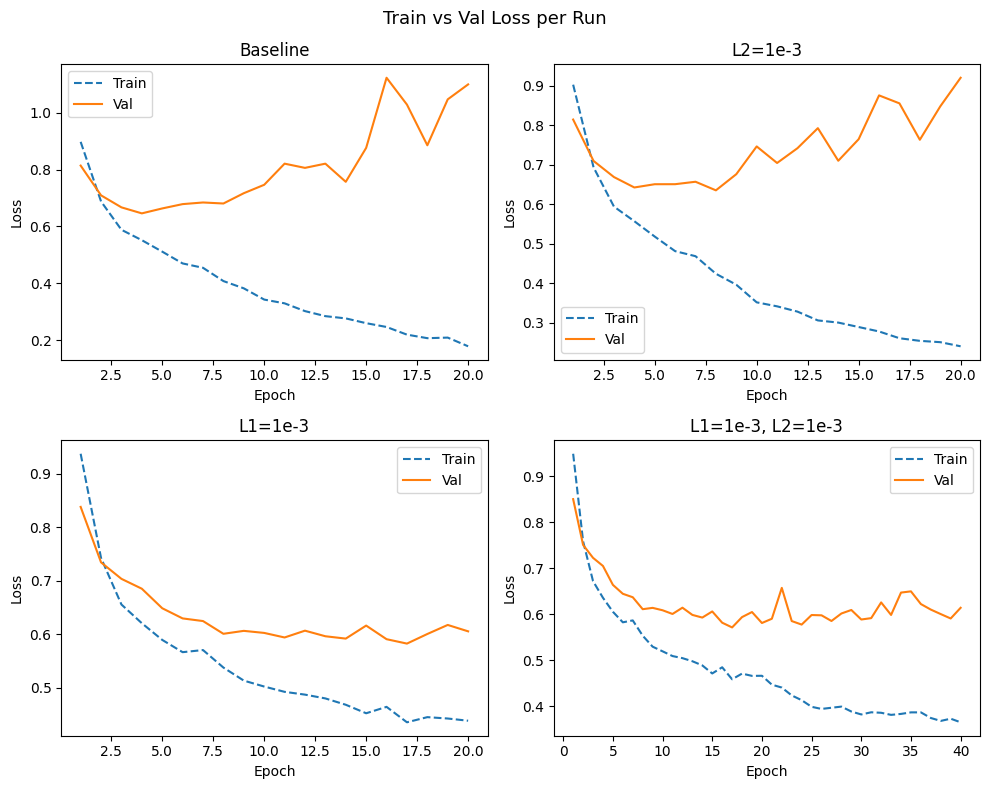

In [13]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_loss'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val Loss per Run', fontsize=13)
plt.tight_layout()
plt.show()

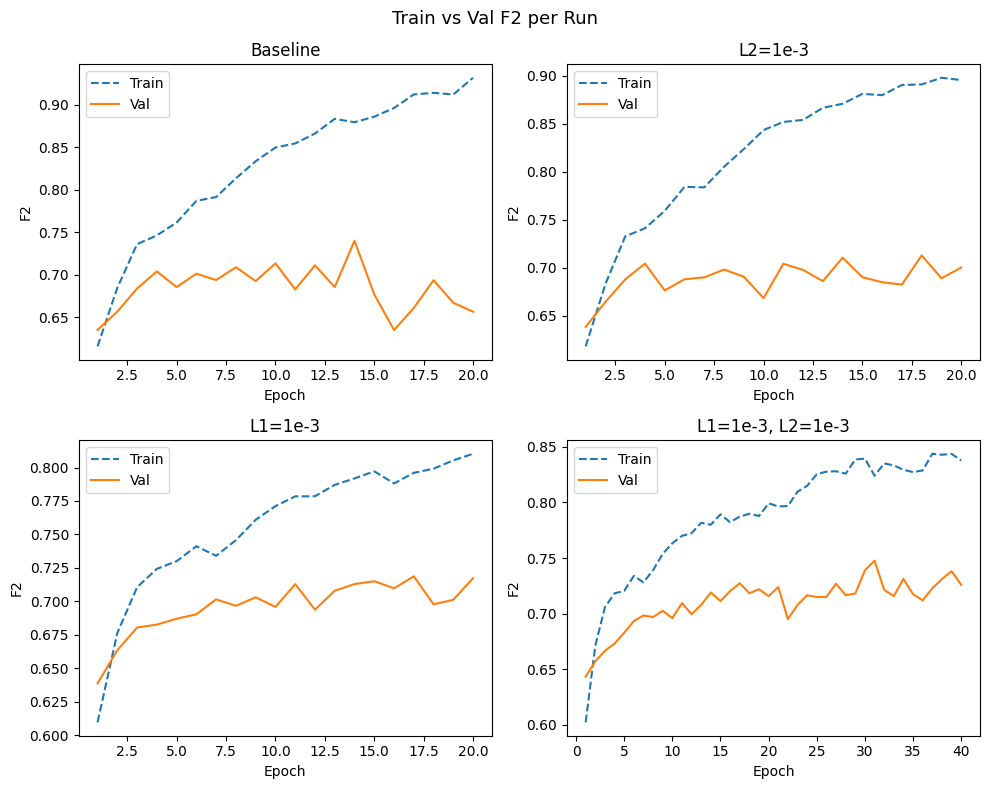

In [14]:
n_runs = len(all_results)
n_cols = 2
n_rows = (n_runs + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows), sharey=False)
axes = axes.flatten()

for ax, (run_label, result) in zip(axes, all_results.items()):
    h = result['history']
    epochs = range(1, len(h['train_f2']) + 1)
    ax.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax.plot(epochs, h['val_f2'], label='Val')
    ax.set_title(run_label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F2')
    ax.legend()

for ax in axes[n_runs:]:
    ax.set_visible(False)

fig.suptitle('Train vs Val F2 per Run', fontsize=13)
plt.tight_layout()
plt.show()

## Save & Evaluate Best Run

In [15]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_mobilenet_v3_small(num_classes=1, unfreeze_last_n_blocks=3).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

torch.save(best_model.state_dict(), '../../models/mobilenet_v3_small_partial_unfreeze_penalty_best.pth')
print('Saved to models/mobilenet_v3_small_partial_unfreeze_penalty_best.pth')

Best run: L1=1e-3, L2=1e-3 (val F2 = 0.7476)
Saved to models/mobilenet_v3_small_partial_unfreeze_penalty_best.pth


## Threshold Tuning

In [16]:
best_model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = best_model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [
    fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0)
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Best threshold: 0.50 | Val F2: 0.7476


## Test Set Evaluation

In [17]:
best_model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[867 139]
 [ 30 137]]

              precision    recall  f1-score   support

           0     0.9666    0.8618    0.9112      1006
           1     0.4964    0.8204    0.6185       167

    accuracy                         0.8559      1173
   macro avg     0.7315    0.8411    0.7649      1173
weighted avg     0.8996    0.8559    0.8695      1173



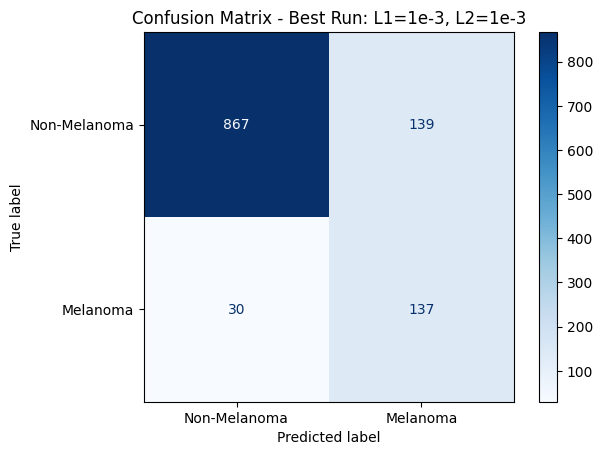

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Best Run: {best_run_label}')
plt.show()